In [0]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px

from sklearn.preprocessing import LabelEncoder

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

df = spark.read.csv('dbfs:/FileStore/tables/Mall_Customers.csv', header=True, inferSchema=True)



In [0]:
#to import the data 
from pyspark.sql import SQLContext # imports SQlContext
sqlContext = SQLContext(sc) # creates the SQL context
spark_df = sqlContext.sql("Select * from Mall_Customers") # Gets the data and saves it as spark_df

In [0]:
#to see the first rows
spark_df_main = spark.createDataFrame(df.head(10))
display(spark_df_main)




CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40
6,Female,22,17,76
7,Female,35,18,6
8,Female,23,18,94
9,Male,64,19,3
10,Female,30,19,72


In [0]:
#to see the last rows 
spark_df_main = spark.createDataFrame(df.tail(10))
display(spark_df_main)


CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
191,Female,34,103,23
192,Female,32,103,69
193,Male,33,113,8
194,Female,38,113,91
195,Female,47,120,16
196,Female,35,120,79
197,Female,45,126,28
198,Male,32,126,74
199,Male,32,137,18
200,Male,30,137,83


In [0]:
# to see the number of columns and rows 
num_rows = df.count()
num_cols = len(df.columns)
print(f"Number of Rows: {num_rows}")
print(f"Number of Columns: {num_cols}")

Number of Rows: 200
Number of Columns: 5


In [0]:
#to check in missing values 
from pyspark.sql.functions import col, count, when

missing_percentage = df.select([(count(when(col(c).isNull(), c))/num_rows).alias(c) for c in df.columns])
missing_percentage.show()


+----------+------+---+------------------+----------------------+
|CustomerID|Gender|Age|Annual Income (k$)|Spending Score (1-100)|
+----------+------+---+------------------+----------------------+
|       0.0|   0.0|0.0|               0.0|                   0.0|
+----------+------+---+------------------+----------------------+



In [0]:
#to check on duplicates 
from pyspark.sql import functions as F

# Get all unique rows
unique_rows = df.dropDuplicates()

# Subtract unique rows from the original df to get duplicates
duplicated_rows = df.subtract(unique_rows)

# Show the duplicated rows
duplicated_rows.show()


+----------+------+---+------------------+----------------------+
|CustomerID|Gender|Age|Annual Income (k$)|Spending Score (1-100)|
+----------+------+---+------------------+----------------------+
+----------+------+---+------------------+----------------------+



In [0]:
# to find out some statistics 
summary = df.describe()
summary.show()


+-------+------------------+------+-----------------+------------------+----------------------+
|summary|        CustomerID|Gender|              Age|Annual Income (k$)|Spending Score (1-100)|
+-------+------------------+------+-----------------+------------------+----------------------+
|  count|               200|   200|              200|               200|                   200|
|   mean|             100.5|  null|            38.85|             60.56|                  50.2|
| stddev|57.879184513951124|  null|13.96900733155888| 26.26472116527124|    25.823521668370173|
|    min|                 1|Female|               18|                15|                     1|
|    max|               200|  Male|               70|               137|                    99|
+-------+------------------+------+-----------------+------------------+----------------------+



In [0]:
from pyspark.sql import functions as F

# Compute the number of unique values for each column
unique_counts = [(col, df.select(col).distinct().count()) for col in df.columns]

# Convert the results into a readable format
unique_counts_df = spark.createDataFrame(unique_counts, ["Column", "NUnique"])
unique_counts_df.show()


+--------------------+-------+
|              Column|NUnique|
+--------------------+-------+
|          CustomerID|    200|
|              Gender|      2|
|                 Age|     51|
|  Annual Income (k$)|     64|
|Spending Score (1...|     84|
+--------------------+-------+



In [0]:
#change the names 

df = df.withColumnRenamed("Annual Income (k$)", "Annual_Income") \
       .withColumnRenamed("Spending Score (1-100)", "Score")

df.columns

Out[15]: ['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Score']

In [0]:
#to count the number of males and females 
gender_counts = df.groupBy("Gender").count().orderBy("count", ascending=False)
gender_counts.show()


+------+-----+
|Gender|count|
+------+-----+
|Female|  112|
|  Male|   88|
+------+-----+



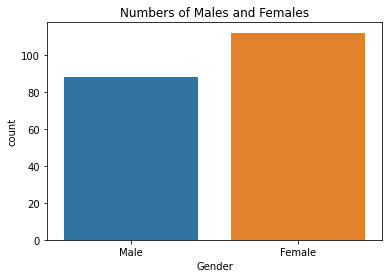

In [0]:
# to visualize the numbers 
df_pandas = df.toPandas()
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Gender', data=df_pandas)
plt.title("Numbers of Males and Females")
plt.show()


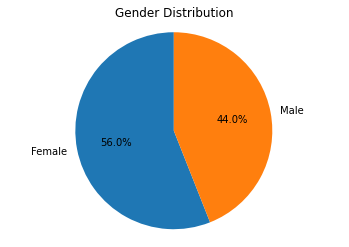

In [0]:
#tpo see the percentage of each 
import matplotlib.pyplot as plt

# Compute gender counts
gender_counts = df_pandas['Gender'].value_counts()

# Plot pie chart
fig, ax = plt.subplots()
ax.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

# Title
plt.title("Gender Distribution")
plt.show()


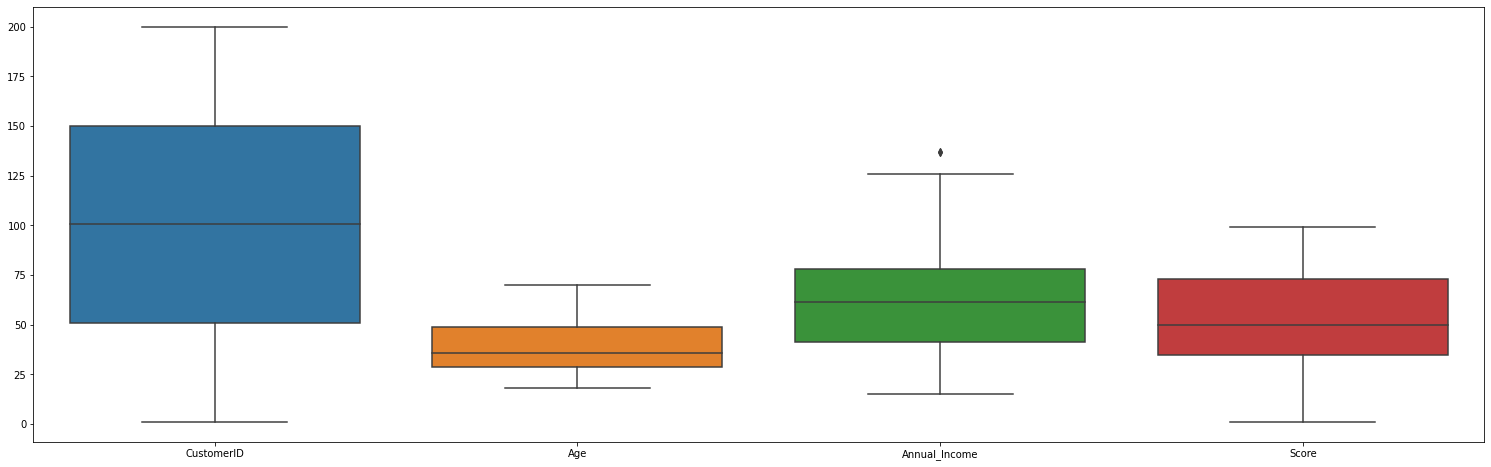

In [0]:
#to check on outliers 
df_pandas = df.toPandas()
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(26, 8))

# Draw the box plot
sns.boxplot(data=df_pandas)

# Show the plot
plt.show()


In [0]:
quantiles = df.approxQuantile("Annual_Income", [0.25, 0.75], 0.05)
Q1 = quantiles[0]
Q3 = quantiles[1]
IQR = Q3 - Q1

# Define bounds for the outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_no_outliers = df.filter((df["Annual_Income"] >= lower_bound) & (df["Annual_Income"] <= upper_bound))


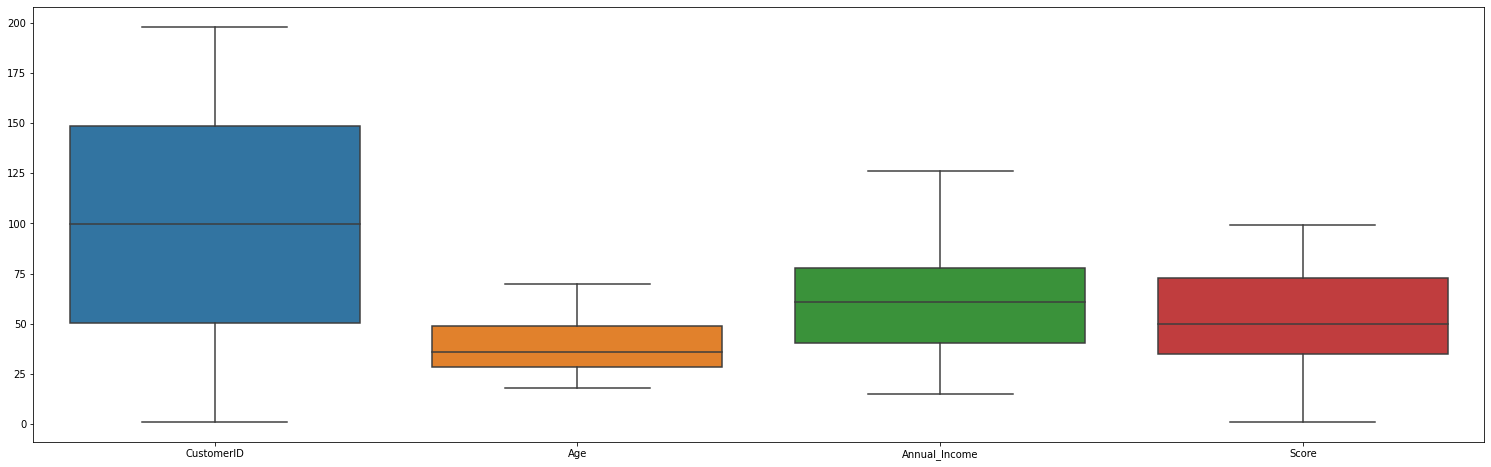

In [0]:
#to get rid of outliers 

df_no_outliers_pandas = df_no_outliers.toPandas()
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(26, 8))

# Draw the box plot
sns.boxplot(data=df_no_outliers_pandas)

# Show the plot
plt.show()


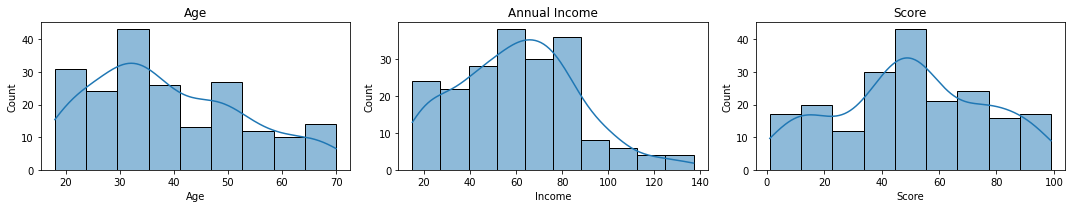

In [0]:
#to create a histogram that summarizes the count of each feature 
df_pandas = df.toPandas()
import seaborn as sns
import matplotlib.pyplot as plt

# Set the figure size
plt.figure(figsize=(15, 3))

# Histogram for Age
plt.subplot(1, 3, 1)
sns.histplot(df_pandas.Age, kde=True)
plt.title("Age")
plt.xlabel("Age")

# Histogram for Annual Income
plt.subplot(1, 3, 2)
sns.histplot(df_pandas.Annual_Income, kde=True)
plt.title("Annual Income")
plt.xlabel("Income")

# Histogram for Score
plt.subplot(1, 3, 3)
sns.histplot(df_pandas.Score, kde=True)
plt.title("Score")
plt.xlabel("Score")

# Show the plots
plt.tight_layout()
plt.show()


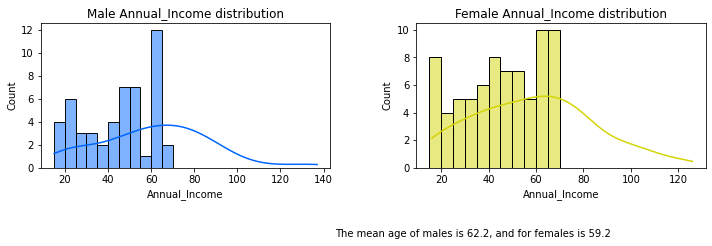

In [0]:

#to check on the mean age of females and males with respect to annula income 

df_pandas = df.toPandas()
import seaborn as sns
import matplotlib.pyplot as plt

# Filter out data for males and females
male = df_pandas[df_pandas.Gender == "Male"]["Annual_Income"]
female = df_pandas[df_pandas.Gender != "Male"]["Annual_Income"]

# Set up the plots
plt.figure(figsize=(10, 4))

# Histogram for Male Age Distribution
plt.subplot(1, 2, 1)
sns.histplot(male, color='#0066ff', bins=range(15, 75, 5), kde=True)
plt.title("Male Annual_Income distribution")

# Histogram for Female Age Distribution
plt.subplot(1, 2, 2)
sns.histplot(female, color='#D4D404', bins=range(15, 75, 5), kde=True)
plt.title("Female Annual_Income distribution")

# Display the mean ages for males and females
plt.text(-25, -5, f"The mean age of males is {round(male.mean(), 1)}, and for females is {round(female.mean(), 1)}")

plt.tight_layout()
plt.show()


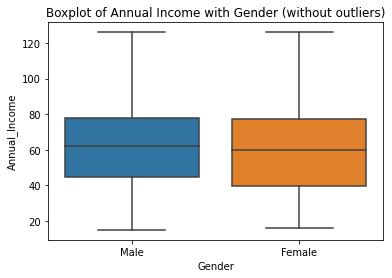

In [0]:
# to check if there is an outlier in the men's annual income 
df_no_outliers_pandas = df_no_outliers.toPandas()
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the plot
plt.figure(figsize=(6, 4))

# Create the boxplot using the data from df_no_outliers_pandas
sns.boxplot(x='Gender', y='Annual_Income', data=df_no_outliers_pandas)
plt.title("Boxplot of Annual Income with Gender (without outliers)")

# Display the plot
plt.show()


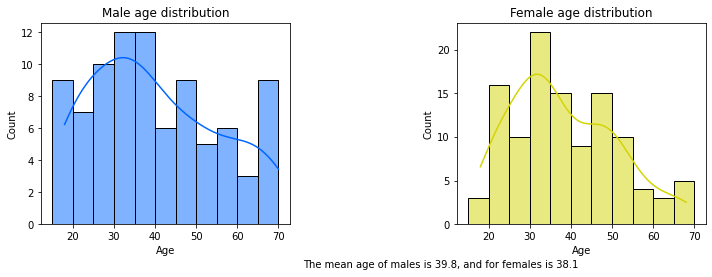

In [0]:
#to check on the mean age of females and males with respect to age distribution 
import seaborn as sns
import matplotlib.pyplot as plt

# Filter out data for males and females
male = df_pandas[df_pandas.Gender == "Male"]["Age"]
female = df_pandas[df_pandas.Gender != "Male"]["Age"]

# Set up the plots
plt.figure(figsize=(10, 4))

# Histogram for Male Age Distribution
plt.subplot(1, 2, 1)
sns.histplot(male, color='#0066ff', bins=range(15, 75, 5), kde=True)
plt.title("Male age distribution")

# Histogram for Female Age Distribution
plt.subplot(1, 2, 2)
sns.histplot(female, color='#D4D404', bins=range(15, 75, 5), kde=True)
plt.title("Female age distribution")

# Display the mean ages for males and females
plt.text(-25, -5, f"The mean age of males is {round(male.mean(), 1)}, and for females is {round(female.mean(), 1)}")

plt.tight_layout()
plt.show()


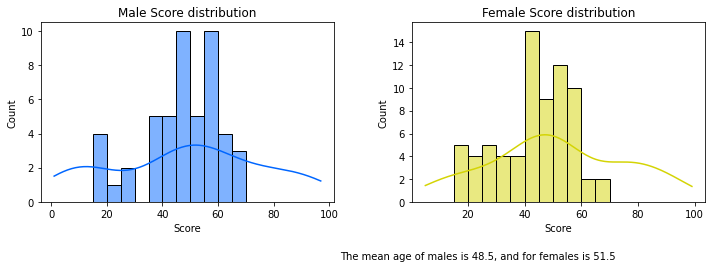

In [0]:
#to check on the mean age of females and males with respect to score distribution 
df_pandas = df.toPandas()
import seaborn as sns
import matplotlib.pyplot as plt

# Filter out data for males and females
male = df_pandas[df_pandas.Gender == "Male"]["Score"]
female = df_pandas[df_pandas.Gender != "Male"]["Score"]

# Set up the plots
plt.figure(figsize=(10, 4))

# Histogram for Male Age Distribution
plt.subplot(1, 2, 1)
sns.histplot(male, color='#0066ff', bins=range(15, 75, 5), kde=True)
plt.title("Male Score distribution")

# Histogram for Female Age Distribution
plt.subplot(1, 2, 2)
sns.histplot(female, color='#D4D404', bins=range(15, 75, 5), kde=True)
plt.title("Female Score distribution")

# Display the mean ages for males and females
plt.text(-25, -5, f"The mean age of males is {round(male.mean(), 1)}, and for females is {round(female.mean(), 1)}")

plt.tight_layout()
plt.show()


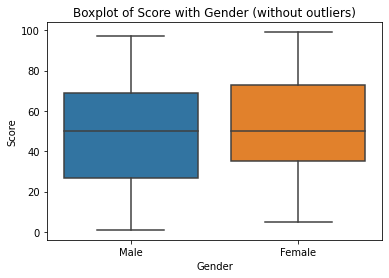

In [0]:
#to check if there is an outlier when checking on score and gender
df_no_outliers_pandas = df_no_outliers.toPandas()
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the plot
plt.figure(figsize=(6, 4))

# Create the boxplot using the data from df_no_outliers_pandas
sns.boxplot(x='Gender', y='Score', data=df_no_outliers_pandas)
plt.title("Boxplot of Score with Gender (without outliers)")

# Display the plot
plt.show()



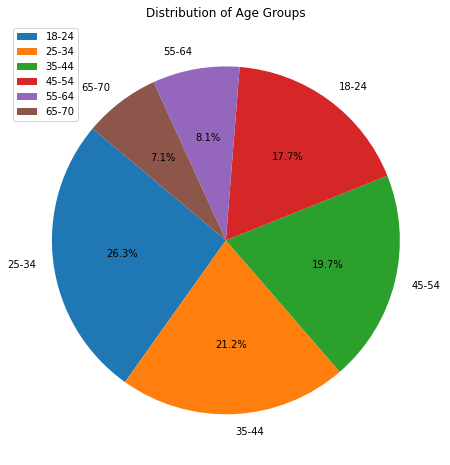

In [0]:
#here I created age ranges to check on their distribution 
from pyspark.sql.functions import when

df_no_outliers = df_no_outliers.withColumn(
    "Age_Group",
    when(df_no_outliers["Age"].between(18, 24), "18-24")
    .when(df_no_outliers["Age"].between(25, 34), "25-34")
    .when(df_no_outliers["Age"].between(35, 44), "35-44")
    .when(df_no_outliers["Age"].between(45, 54), "45-54")
    .when(df_no_outliers["Age"].between(55, 64), "55-64")
    .otherwise("65-70")
)

df_no_outliers_pandas = df_no_outliers.toPandas()

import matplotlib.pyplot as plt

# Prepare the data for the pie chart
age_group_counts = df_no_outliers_pandas.Age_Group.value_counts()

# Plot the pie chart
plt.figure(figsize=(8, 8))
plt.pie(age_group_counts, labels=age_group_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Age Groups')
plt.legend(['18-24', '25-34', '35-44', '45-54', '55-64', '65-70'])
plt.show()


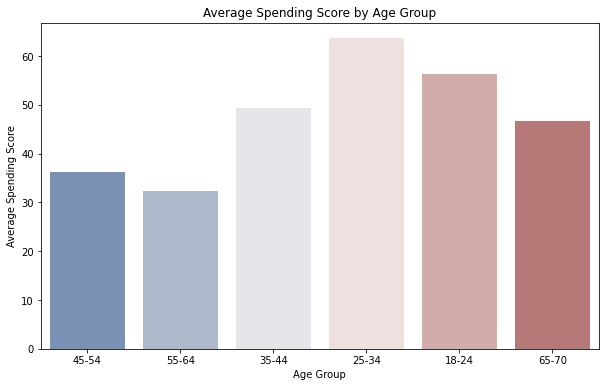

In [0]:
# here I used this code to check on the average spending score by age group 

from pyspark.sql import functions as F

mean_score_df = df_no_outliers.groupBy("Age_Group").agg(F.mean("Score").alias("Average_Score"))


import seaborn as sns
import matplotlib.pyplot as plt

mean_score_pandas = mean_score_df.toPandas()
# Plot the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=mean_score_pandas["Age_Group"], y=mean_score_pandas["Average_Score"], palette="vlag")
plt.title("Average Spending Score by Age Group")
plt.ylabel("Average Spending Score")
plt.xlabel("Age Group")
plt.show()





Out[30]: <seaborn.axisgrid.PairGrid at 0x7fdba990b4f0>

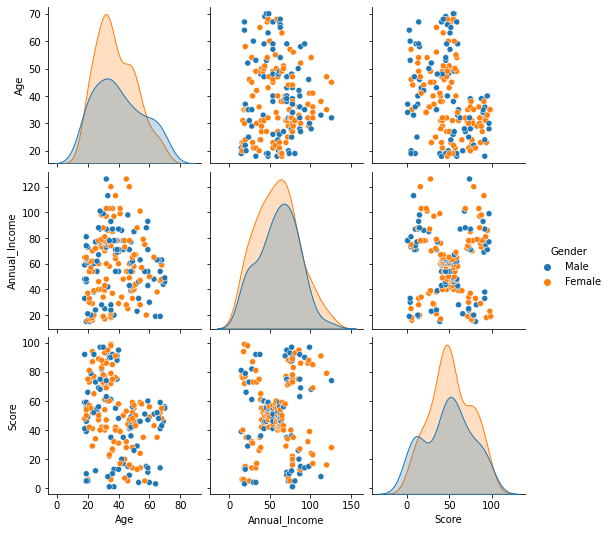

In [0]:
#I dropped the CustomerID column since ti has no contribution and also created a pairplot 
df_no_id = df_no_outliers.drop("CustomerID")
df_no_id_pandas = df_no_id.toPandas()
import seaborn as sns 

# Plot the pairplot
sns.pairplot(df_no_id_pandas, hue="Gender")


In [0]:
#previously i dropped the CustomerID column and now I converted the binary feature and also I dropped the gender feature since it has no big variation 
from pyspark.ml.feature import StringIndexer

# Create a copy of the df_no_outliers dataframe
X = df_no_outliers

# Drop the "CustomerID" and original "Gender" column
X = X.drop("CustomerID", "Gender", "GenderEncoder")


# Display the top rows
X.show()


+---+-------------+-----+---------+
|Age|Annual_Income|Score|Age_Group|
+---+-------------+-----+---------+
| 19|           15|   39|    18-24|
| 21|           15|   81|    18-24|
| 20|           16|    6|    18-24|
| 23|           16|   77|    18-24|
| 31|           17|   40|    25-34|
| 22|           17|   76|    18-24|
| 35|           18|    6|    35-44|
| 23|           18|   94|    18-24|
| 64|           19|    3|    55-64|
| 30|           19|   72|    25-34|
| 67|           19|   14|    65-70|
| 35|           19|   99|    35-44|
| 58|           20|   15|    55-64|
| 24|           20|   77|    18-24|
| 37|           20|   13|    35-44|
| 22|           20|   79|    18-24|
| 35|           21|   35|    35-44|
| 20|           21|   66|    18-24|
| 52|           23|   29|    45-54|
| 35|           23|   98|    35-44|
+---+-------------+-----+---------+
only showing top 20 rows



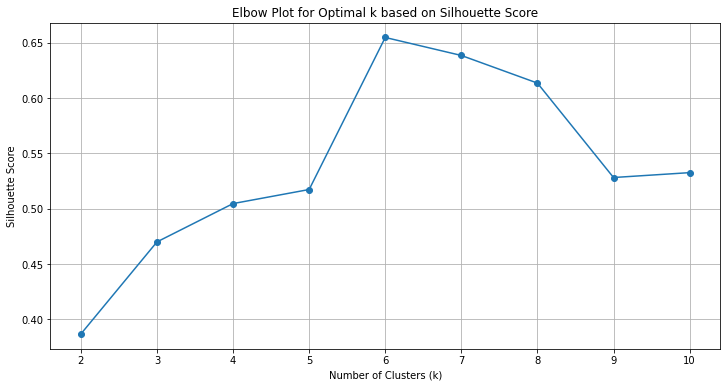

In [0]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import ClusteringEvaluator
import matplotlib.pyplot as plt

# Convert features to vector format for PySpark ML
features = ['Age', 'Annual_Income', 'Score']
vec_assembler = VectorAssembler(inputCols=features, outputCol="features")
X_vec = vec_assembler.transform(X)

silhouette_scores = []
k_range = range(2, 11)

# Calculate silhouette scores for each k
for k in k_range:
    kmeans = KMeans().setK(k).setSeed(0).setFeaturesCol("features")
    model = kmeans.fit(X_vec)
    predictions = model.transform(X_vec)
    evaluator = ClusteringEvaluator()
    silhouette = evaluator.evaluate(predictions)
    silhouette_scores.append(silhouette)

# Plot the silhouette scores
plt.figure(figsize=(12, 6))
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Elbow Plot for Optimal k based on Silhouette Score')
plt.grid(True)
plt.show()


In [0]:

from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import ClusteringEvaluator

# Convert features to vector format for PySpark ML
features = ['Age', 'Annual_Income', 'Score']
vec_assembler = VectorAssembler(inputCols=features, outputCol="features")
X_vec = vec_assembler.transform(X)

kmeans_5 = KMeans().setK(5).setSeed(0).setFeaturesCol("features")
model_5 = kmeans_5.fit(X_vec)
transformed_5 = model_5.transform(X_vec)

# Compute Silhouette score
evaluator = ClusteringEvaluator()
silhouette = evaluator.evaluate(transformed_5)
print("Silhouette Score of 5 clusters:", silhouette)

# Adding cluster result back to dataframe
X_with_cluster = X.join(transformed_5, on=features, how='inner').select(*features, 'prediction')
X_with_cluster = X_with_cluster.withColumnRenamed('prediction', 'Cluster')



Silhouette Score of 5 clusters: 0.5173105885269527


Out[34]: Text(0, 0.5, 'Shopping Score')

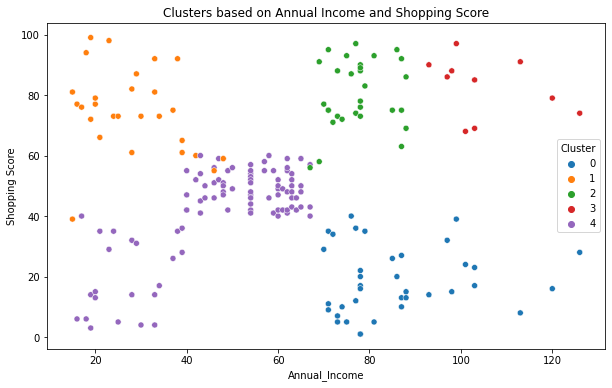

In [0]:
#to find clusters based on annual income and shopping score 
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the Spark DataFrame to pandas for visualization
X_with_cluster_pd = X_with_cluster.toPandas()

# Visualize using seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Annual_Income", y="Score", hue="Cluster", data=X_with_cluster_pd, palette='tab10')
plt.title("Clusters based on Annual Income and Shopping Score")
plt.ylabel("Shopping Score")


Out[35]: Text(0, 0.5, 'Shopping Score')

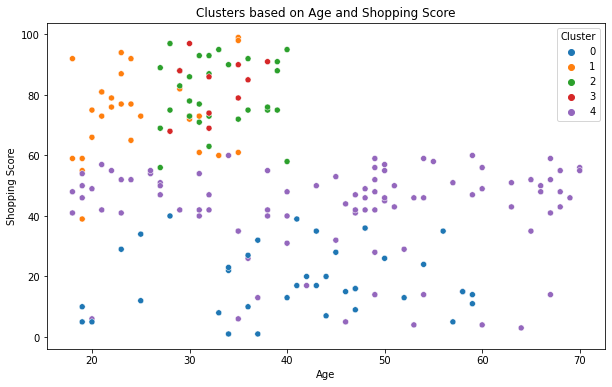

In [0]:
#to find clusters based on age and shopping score 
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the Spark DataFrame to pandas for visualization
X_with_cluster_pd = X_with_cluster.toPandas()

# Visualize using seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Age", y="Score", hue="Cluster", data=X_with_cluster_pd, palette='tab10')
plt.title("Clusters based on Age and Shopping Score")
plt.ylabel("Shopping Score")


In [0]:
#to find the size of each cluster 
from pyspark.sql import functions as F

KM_clust_sizes = X_with_cluster.groupBy('Cluster').agg(F.count('*').alias('KM_size'))

KM_clust_sizes_pd = KM_clust_sizes.toPandas()
print(KM_clust_sizes_pd)





   Cluster  KM_size
0        1       28
1        3       10
2        4       93
3        2       30
4        0       37


In [0]:
#creating a 3D visual fro the 5 clusters 
from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler

# Assemble features for clustering
vec_assembler = VectorAssembler(inputCols=["Age", "Annual_Income", "Score"], outputCol="features")
X = vec_assembler.transform(df_no_outliers)

# Use KMeans to cluster the data
kmeans = KMeans().setK(5).setSeed(1)
model = kmeans.fit(X)
X_with_cluster = model.transform(X)

KM_5_pd = X_with_cluster.toPandas()

import plotly.express as px

fig = px.scatter_3d(KM_5_pd, x="Age", y="Annual_Income", z="Score", color='prediction', opacity=0.7)
fig.show()


/databricks/spark/python/pyspark/sql/pandas/conversion.py:122: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  Unable to convert the field features. If this column is not necessary, you may consider dropping it or converting to primitive type before the conversion.
Direct cause: Unsupported type in conversion to Arrow: VectorUDT()
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


In [0]:
#to better understand the bounds of clusters I found the Max, Min, and Average 

from pyspark.sql import functions as F

bounds_and_avg = X_with_cluster.groupBy("prediction")\
    .agg(
        F.min("Age").alias("min_age"),
        F.max("Age").alias("max_age"),
        F.avg("Age").alias("avg_age"),
        
        F.min("Annual_Income").alias("min_annual_income"),
        F.max("Annual_Income").alias("max_annual_income"),
        F.avg("Annual_Income").alias("avg_annual_income"),
        
        F.min("Score").alias("min_score"),
        F.max("Score").alias("max_score"),
        F.avg("Score").alias("avg_score")
    )\
    .orderBy("prediction")

bounds_and_avg.show()


+----------+-------+-------+------------------+-----------------+-----------------+------------------+---------+---------+------------------+
|prediction|min_age|max_age|           avg_age|min_annual_income|max_annual_income| avg_annual_income|min_score|max_score|         avg_score|
+----------+-------+-------+------------------+-----------------+-----------------+------------------+---------+---------+------------------+
|         0|     18|     35|              24.8|               15|               67|             41.46|       41|       99|              63.7|
|         1|     19|     67|44.142857142857146|               15|               39|25.142857142857142|        3|       40|19.523809523809526|
|         2|     32|     70| 53.71153846153846|               38|               69| 54.42307692307692|       35|       60| 48.73076923076923|
|         3|     19|     59| 40.62162162162162|               70|              126| 85.64864864864865|        1|       40| 18.64864864864865|
|     

In [0]:
#Silhouette Score for Clusters

from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import ClusteringEvaluator

# Convert features to vector format for PySpark ML
features = ['Age', 'Annual_Income', 'Score']
vec_assembler = VectorAssembler(inputCols=features, outputCol="features")


# Use KMeans to cluster the data with 6 clusters
# Use KMeans to cluster the data with 6 clusters
kmeans_6 = KMeans().setK(6).setSeed(0).setFeaturesCol("features")
model_6 = kmeans_6.fit(X_vec)
transformed_6 = model_6.transform(X_vec)

# Compute Silhouette score
evaluator = ClusteringEvaluator()
silhouette = evaluator.evaluate(transformed_6)
print("Silhouette Score of 6 clusters:", silhouette)

# Adding cluster result back to dataframe
X_with_cluster = X.join(transformed_6, on=features, how='inner').select(*features, 'prediction')
X_with_cluster = X_with_cluster.withColumnRenamed('prediction', 'Cluster')




Silhouette Score of 6 clusters: 0.6547999525720961


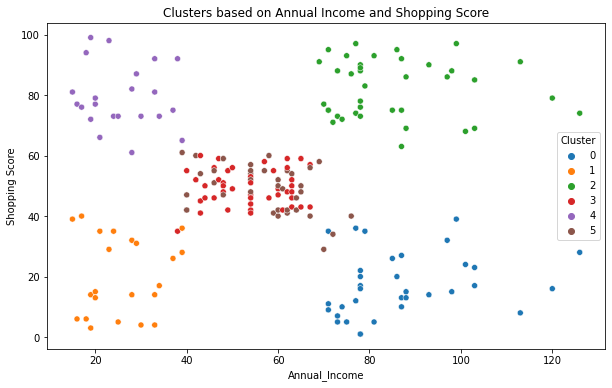

In [0]:
#to find clusters based on annual income and shopping score 
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the Spark DataFrame with 6 clusters to pandas for visualization
X_with_cluster_pd = X_with_cluster.toPandas()

# Visualize using seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Annual_Income", y="Score", hue="Cluster", data=X_with_cluster_pd, palette='tab10')
plt.title("Clusters based on Annual Income and Shopping Score")
plt.ylabel("Shopping Score")
plt.show()  # Use plt.show() to display the plot


Out[41]: Text(0, 0.5, 'Shopping Score')

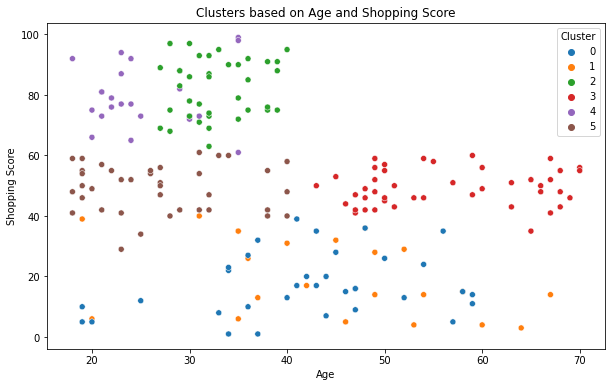

In [0]:
#to find clusters based on age and shopping score 
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the Spark DataFrame to pandas for visualization
X_with_cluster_pd = X_with_cluster.toPandas()

# Visualize using seaborn
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Age", y="Score", hue="Cluster", data=X_with_cluster_pd, palette='tab10')
plt.title("Clusters based on Age and Shopping Score")
plt.ylabel("Shopping Score")


In [0]:
#to find the size of each cluster 
from pyspark.sql import functions as F

KM_clust_sizes = X_with_cluster.groupBy('Cluster').agg(F.count('*').alias('KM_size'))

KM_clust_sizes_pd = KM_clust_sizes.toPandas()
print(KM_clust_sizes_pd)

   Cluster  KM_size
0        1       22
1        3       44
2        5       38
3        4       22
4        2       38
5        0       34


In [0]:
#to see the 3d visual for the 6 clusters

from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler

# Assemble features for clustering
vec_assembler = VectorAssembler(inputCols=["Age", "Annual_Income", "Score"], outputCol="features")
X = vec_assembler.transform(df_no_outliers)

# Use KMeans to cluster the data with 6 clusters
kmeans = KMeans().setK(6).setSeed(1)
model = kmeans.fit(X)
X_with_cluster = model.transform(X)

KM_6_pd = X_with_cluster.toPandas()

import plotly.express as px

fig = px.scatter_3d(KM_6_pd, x="Age", y="Annual_Income", z="Score", color='prediction', opacity=0.7)
fig.show()


/databricks/spark/python/pyspark/sql/pandas/conversion.py:122: UserWarning:

toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  Unable to convert the field features. If this column is not necessary, you may consider dropping it or converting to primitive type before the conversion.
Direct cause: Unsupported type in conversion to Arrow: VectorUDT()
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.



In [0]:
#to better understand the bounds of clusters I found the Max, Min, and Average 
from pyspark.sql import functions as F

bounds_and_avg = X_with_cluster.groupBy("prediction")\
    .agg(
        F.min("Age").alias("min_age"),
        F.max("Age").alias("max_age"),
        F.avg("Age").alias("avg_age"),
        
        F.min("Annual_Income").alias("min_annual_income"),
        F.max("Annual_Income").alias("max_annual_income"),
        F.avg("Annual_Income").alias("avg_annual_income"),
        
        F.min("Score").alias("min_score"),
        F.max("Score").alias("max_score"),
        F.avg("Score").alias("avg_score")
    )\
    .orderBy("prediction")

bounds_and_avg.show()

+----------+-------+-------+------------------+-----------------+-----------------+------------------+---------+---------+------------------+
|prediction|min_age|max_age|           avg_age|min_annual_income|max_annual_income| avg_annual_income|min_score|max_score|         avg_score|
+----------+-------+-------+------------------+-----------------+-----------------+------------------+---------+---------+------------------+
|         0|     27|     40| 32.76315789473684|               69|              126| 85.21052631578948|       63|       97| 82.10526315789474|
|         1|     19|     67|44.142857142857146|               15|               39|25.142857142857142|        3|       40|19.523809523809526|
|         2|     18|     40|              27.0|               39|               76|  56.6578947368421|       29|       61| 49.13157894736842|
|         3|     18|     35|25.272727272727273|               15|               39|25.727272727272727|       61|       99| 79.36363636363636|
|     